# 02 Exploratory Data Analysis: Parkinson’s Voice Biomarkers

This notebook explores whether biomedical voice measurements contain measurable biomarkers associated with Parkinson’s disease. The analysis compares healthy controls and Parkinson’s disease patients across frequency, jitter, shimmer, noise, and nonlinear vocal features.

Because the dataset contains multiple recordings from the same individuals, the analysis distinguishes between recording-level summaries and patient-level summaries.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
data_path = "../data/processed/parkinsons_cleaned.csv"

df = pd.read_csv(data_path)

df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,patient_id
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,S01
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,S01
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,S01
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,S01
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,S01


In [3]:
print("Number of voice recordings:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Number of extracted patient IDs:", df["patient_id"].nunique())

df.info()

Number of voice recordings: 195
Number of columns: 25
Number of extracted patient IDs: 32
<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR         

## Voice Biomarker Groups

The voice measurements are grouped by the type of vocal characteristic they describe:

- **Frequency features** measure vocal pitch.
- **Jitter features** measure variation in vocal frequency.
- **Shimmer features** measure variation in vocal amplitude or loudness.
- **Noise features** measure the relationship between noisy and harmonic components of the voice.
- **Nonlinear features** measure more complex irregularities in vocal behavior.

In [4]:
frequency_features = [
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)",
    "MDVP:Flo(Hz)"
]

jitter_features = [
    "MDVP:Jitter(%)",
    "MDVP:Jitter(Abs)",
    "MDVP:RAP",
    "MDVP:PPQ",
    "Jitter:DDP"
]

shimmer_features = [
    "MDVP:Shimmer",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "MDVP:APQ",
    "Shimmer:DDA"
]

noise_features = [
    "NHR",
    "HNR"
]

nonlinear_features = [
    "RPDE",
    "DFA",
    "spread1",
    "spread2",
    "D2",
    "PPE"
]

all_feature_columns = (
    frequency_features +
    jitter_features +
    shimmer_features +
    noise_features +
    nonlinear_features
)

target = "status"

In [5]:
status_labels = {
    0: "Healthy",
    1: "Parkinson's"
}

df["diagnosis_label"] = df["status"].map(status_labels)

figures_dir = "../reports/figures/eda"
os.makedirs(figures_dir, exist_ok=True)

df[["name", "patient_id", "status", "diagnosis_label"]].head()

,name,patient_id,status,diagnosis_label
0,phon_R01_S01_1,S01,1,Parkinson's
1,phon_R01_S01_2,S01,1,Parkinson's
2,phon_R01_S01_3,S01,1,Parkinson's
3,phon_R01_S01_4,S01,1,Parkinson's
4,phon_R01_S01_5,S01,1,Parkinson's


## 1. Dataset Overview

This section examines the number of recordings, number of patients, diagnosis distribution, and recording structure.

Because the dataset includes repeated recordings from the same patients, it is important to distinguish between the number of recordings and the number of individuals represented.

In [6]:
recording_class_counts = df["diagnosis_label"].value_counts()
recording_class_percentages = df["diagnosis_label"].value_counts(normalize=True).mul(100).round(2)

recording_summary = pd.DataFrame({
    "Recordings": recording_class_counts,
    "Percentage": recording_class_percentages
})

recording_summary

,Recordings,Percentage
diagnosis_label,,
Parkinson's,147,75.38
Healthy,48,24.62


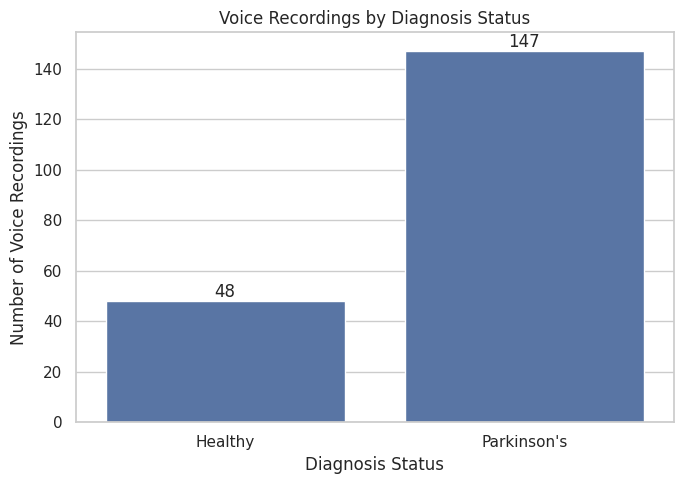

In [7]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="diagnosis_label",
    order=["Healthy", "Parkinson's"]
)

plt.title("Voice Recordings by Diagnosis Status")
plt.xlabel("Diagnosis Status")
plt.ylabel("Number of Voice Recordings")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(f"{figures_dir}/recording_class_distribution.png", dpi=300)
plt.show()

### Recording-Level Class Distribution Analysis

The dataset contains 195 total voice recordings, with 147 recordings from individuals with Parkinson’s disease and 48 recordings from healthy individuals. This means that approximately 75.38% of recordings belong to the Parkinson’s class, while 24.62% belong to the healthy class. Therefore, the dataset is moderately imbalanced toward Parkinson’s recordings. This imbalance must be considered during later machine learning analysis because a model may appear successful by favoring the majority class. Evaluation should therefore include metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrices rather than relying on accuracy alone. Additionally, because multiple recordings come from the same patients, the imbalance and model performance will also need to be evaluated using patient-aware splitting.

In [8]:
patient_status = (
    df[["patient_id", "status"]]
    .drop_duplicates()
    .copy()
)

patient_status["diagnosis_label"] = patient_status["status"].map(status_labels)

patient_class_counts = patient_status["diagnosis_label"].value_counts()
patient_class_percentages = patient_status["diagnosis_label"].value_counts(normalize=True).mul(100).round(2)

patient_summary = pd.DataFrame({
    "Patients": patient_class_counts,
    "Percentage": patient_class_percentages
})

patient_summary

,Patients,Percentage
diagnosis_label,,
Parkinson's,24,75.0
Healthy,8,25.0


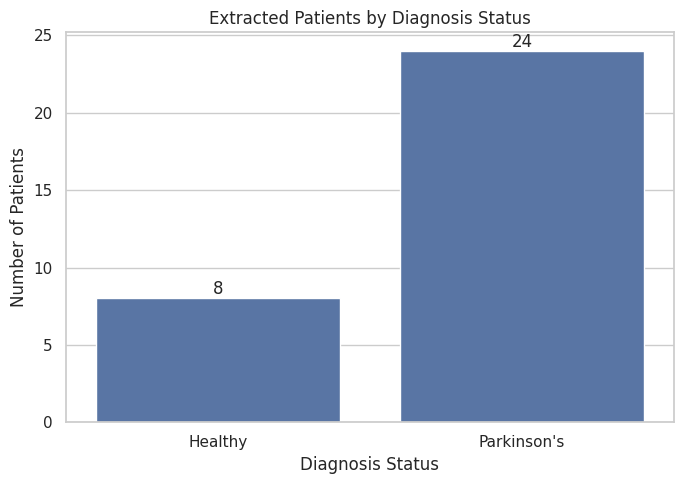

In [9]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=patient_status,
    x="diagnosis_label",
    order=["Healthy", "Parkinson's"]
)

plt.title("Extracted Patients by Diagnosis Status")
plt.xlabel("Diagnosis Status")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(f"{figures_dir}/patient_class_distribution.png", dpi=300)
plt.show()

### Patient-Level Class Distribution Analysis

At the patient level, the extracted subject labels indicate that 24 of 32 patients (75.0%) are associated with Parkinson’s disease, while 8 patients (25.0%) are healthy controls. This distribution remains imbalanced in favor of the Parkinson’s group and is similar to the recording-level distribution, although the patient-level summary is more appropriate for understanding the number of distinct subjects represented rather than the number of voice samples. Because each patient contributes multiple recordings, using only the recording-level counts could overrepresent patients with more samples. Retaining the extracted patient identifiers is still necessary for later patient-aware data splitting so that recordings from the same subject do not appear in both training and testing sets, which would create data leakage.


In [10]:
recordings_per_patient = (
    df.groupby(["patient_id", "diagnosis_label"])
    .size()
    .reset_index(name="recording_count")
)

recordings_per_patient.sort_values("patient_id")

,patient_id,diagnosis_label,recording_count
0,S01,Parkinson's,6
1,S02,Parkinson's,6
2,S04,Parkinson's,6
3,S05,Parkinson's,6
4,S06,Parkinson's,6
5,S07,Healthy,6
6,S08,Parkinson's,6
7,S10,Healthy,6
8,S13,Healthy,6
9,S16,Parkinson's,6


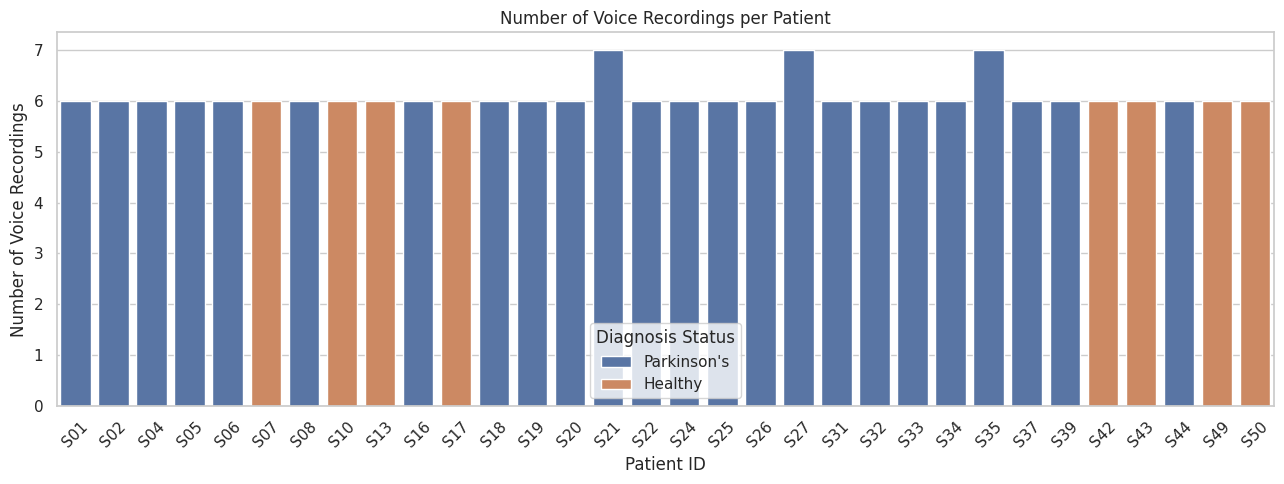

In [11]:
plt.figure(figsize=(13, 5))

sns.barplot(
    data=recordings_per_patient,
    x="patient_id",
    y="recording_count",
    hue="diagnosis_label"
)

plt.title("Number of Voice Recordings per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Number of Voice Recordings")
plt.xticks(rotation=45)
plt.legend(title="Diagnosis Status")

plt.tight_layout()
plt.savefig(f"{figures_dir}/recordings_per_patient.png", dpi=300)
plt.show()

### Recording Structure Analysis

The extracted patient identifiers show that nearly all patients contributed 6 voice recordings, while three patients associated with Parkinson’s disease (`S21`, `S27`, and `S35`) contributed 7 recordings each. This relatively consistent number of recordings per patient indicates that no single subject heavily dominates the dataset; however, the analysis still contains repeated measurements from the same individuals. These recordings are not independent observations because samples from the same patient may share subject-specific vocal characteristics. Therefore, later machine learning models should use patient-aware splitting rather than randomly dividing individual recordings into training and testing sets. A random recording-level split could place recordings from the same patient in both sets, allowing the model to learn patient-specific patterns rather than generalizable vocal biomarkers associated with Parkinson’s disease and potentially producing overly optimistic performance estimates.


## Patient-Level Summary Dataset

The original dataset contains repeated recordings from each patient. For more cautious exploratory comparisons, this section creates a patient-level dataset by calculating the median value of each voice biomarker for each patient.

The median is used because it reduces the influence of unusually high or low individual recordings while preserving each patient’s typical vocal measurement pattern.

In [12]:
patient_df = (
    df.groupby(["patient_id", "status"], as_index=False)[all_feature_columns]
    .median()
)

patient_df["diagnosis_label"] = patient_df["status"].map(status_labels)

print("Recording-level dataset shape:", df.shape)
print("Patient-level dataset shape:", patient_df.shape)

patient_df.head()

Recording-level dataset shape: (195, 26)
Patient-level dataset shape: (32, 25)


,patient_id,status,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,diagnosis_label
0,S01,1,118.3370,139.8260,111.4605,0.009825,0.000085,0.004835,0.007240,0.014495,0.053625,0.4995,0.028405,0.039315,0.036810,0.085205,0.015600,20.6475,0.423625,0.821503,-4.180184,0.305142,2.337219,0.363225,Parkinson's
1,S02,1,95.3930,117.9870,91.4900,0.005185,0.000060,0.002610,0.003310,0.007830,0.021180,0.1940,0.010760,0.013095,0.018045,0.032275,0.010460,21.8370,0.603589,0.774871,-5.374224,0.326882,2.364912,0.240655,Parkinson's
2,S04,1,143.1775,198.2970,79.6600,0.003795,0.000030,0.001610,0.002055,0.004835,0.017350,0.1560,0.008705,0.009520,0.015780,0.026120,0.009400,24.9055,0.520358,0.650437,-5.550128,0.224975,2.235024,0.209027,Parkinson's
3,S05,1,155.1425,182.6135,78.5980,0.006110,0.000040,0.002980,0.003330,0.008940,0.041645,0.3670,0.021040,0.025050,0.042780,0.063120,0.025045,18.5145,0.639285,0.692922,-4.442711,0.262474,2.798193,0.303903,Parkinson's
4,S06,1,158.9630,207.1575,77.7990,0.004990,0.000030,0.002650,0.002640,0.007955,0.018550,0.1770,0.008380,0.011005,0.018125,0.025150,0.012490,25.3985,0.423204,0.725224,-6.227640,0.223584,2.451955,0.155201,Parkinson's


In [13]:
patient_df["diagnosis_label"].value_counts()

diagnosis_label
Parkinson's    24
Healthy         8
Name: count, dtype: int64

### Why Both Versions Are Kept

The recording-level dataset is useful for understanding all recorded measurements and will later support machine learning, provided patient-aware splitting is used.

The patient-level dataset is useful for descriptive comparisons because it prevents patients with more recordings from contributing slightly more influence to group summaries.

## Overall Biomarker Summary Statistics

This section provides summary statistics for the biomedical voice measurements across all recordings.

In [15]:
df[all_feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [16]:
patient_group_means = (
    patient_df.groupby("diagnosis_label")[all_feature_columns]
    .mean()
    .T
)

patient_group_means.columns = ["Healthy Mean", "Parkinson's Mean"]

patient_group_means["Difference"] = (
    patient_group_means["Parkinson's Mean"] -
    patient_group_means["Healthy Mean"]
)

patient_group_means["Percent Difference from Healthy"] = (
    patient_group_means["Difference"] /
    patient_group_means["Healthy Mean"].abs() *
    100
)

patient_group_means

,Healthy Mean,Parkinson's Mean,Difference,Percent Difference from Healthy
MDVP:Fo(Hz),183.132750,144.180896,-38.951854,-21.269737
MDVP:Fhi(Hz),207.743750,177.773000,-29.970750,-14.426788
MDVP:Flo(Hz),150.178125,107.214354,-42.963771,-28.608541
MDVP:Jitter(%),0.003613,0.006413,0.002799,77.477945
MDVP:Jitter(Abs),0.000022,0.000047,0.000025,115.854823
MDVP:RAP,0.001809,0.003436,0.001626,89.890616
MDVP:PPQ,0.001973,0.003655,0.001682,85.297845
Jitter:DDP,0.005428,0.010307,0.004879,89.890616
MDVP:Shimmer,0.017476,0.031651,0.014175,81.110078
MDVP:Shimmer(dB),0.162438,0.299687,0.137250,84.494036


In [17]:
patient_group_means["Absolute Percent Difference"] = (
    patient_group_means["Percent Difference from Healthy"].abs()
)

patient_group_means.sort_values(
    "Absolute Percent Difference",
    ascending=False
)

,Healthy Mean,Parkinson's Mean,Difference,Percent Difference from Healthy,Absolute Percent Difference
NHR,0.010080,0.024513,0.014433,143.185764,143.185764
MDVP:Jitter(Abs),0.000022,0.000047,0.000025,115.854823,115.854823
MDVP:APQ,0.013254,0.025950,0.012696,95.793643,95.793643
PPE,0.120151,0.233099,0.112948,94.004785,94.004785
MDVP:RAP,0.001809,0.003436,0.001626,89.890616,89.890616
Jitter:DDP,0.005428,0.010307,0.004879,89.890616,89.890616
MDVP:PPQ,0.001973,0.003655,0.001682,85.297845,85.297845
MDVP:Shimmer(dB),0.162438,0.299687,0.137250,84.494036,84.494036
Shimmer:APQ5,0.010412,0.019074,0.008662,83.185274,83.185274
MDVP:Shimmer,0.017476,0.031651,0.014175,81.110078,81.110078


### Initial Biomarker Summary Analysis

The initial recording-level summary reveals several notable differences in average vocal biomarker values between the two diagnosis groups. Recordings associated with Parkinson’s disease show higher mean values for all jitter measures, all shimmer measures, NHR, RPDE, DFA, spread1, spread2, D2, and PPE. In contrast, the Parkinson’s group shows lower average fundamental frequency measures (MDVP:Fo(Hz), MDVP:Fhi(Hz), and MDVP:Flo(Hz)) and lower HNR. The largest relative differences are observed in NHR, which is approximately 143% higher in the Parkinson’s group, followed by MDVP:Jitter(Abs) at approximately 116% higher, MDVP:APQ at approximately 96% higher, and PPE at approximately 94% higher. The consistent elevation across the jitter and shimmer feature groups suggests that measures of frequency and amplitude variation may be especially important vocal biomarkers for distinguishing patterns associated with Parkinson’s disease in this dataset. The higher NHR and lower HNR values also indicate group-level differences in measures related to vocal noise and harmonic quality. However, these observations are descriptive rather than diagnostic, and because this comparison is based on repeated voice recordings from a small number of patients, later patient-level analysis and patient-aware modeling will be necessary to evaluate whether these patterns remain meaningful without subject-level leakage.

## 4. Frequency Features

Frequency features measure vocal pitch:

- `MDVP:Fo(Hz)` = average vocal fundamental frequency
- `MDVP:Fhi(Hz)` = maximum vocal fundamental frequency
- `MDVP:Flo(Hz)` = minimum vocal fundamental frequency

This analysis explores whether patients with Parkinson’s disease show different pitch-related vocal measurements than healthy patients.

In [18]:
patient_df.groupby("diagnosis_label")[frequency_features].mean().T

diagnosis_label,Healthy,Parkinson's
MDVP:Fo(Hz),183.132750,144.180896
MDVP:Fhi(Hz),207.743750,177.773000
MDVP:Flo(Hz),150.178125,107.214354


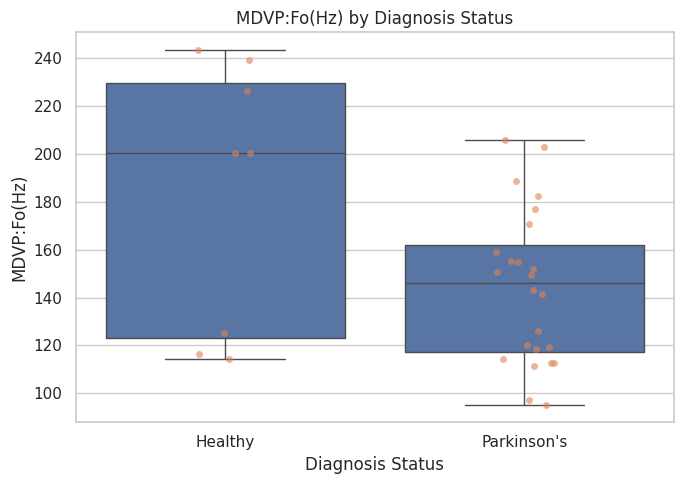

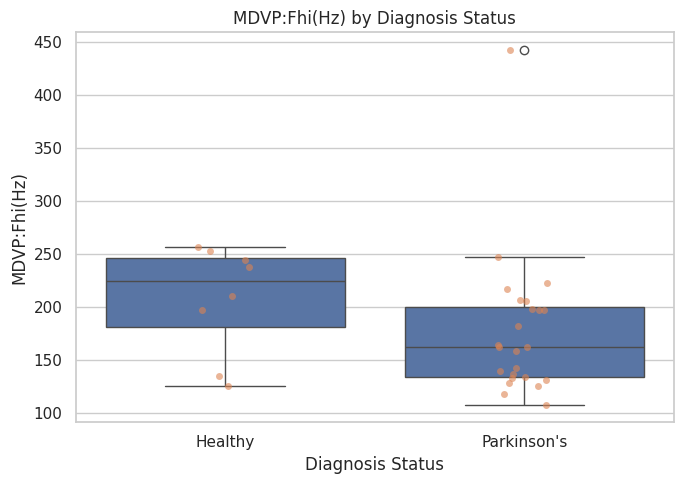

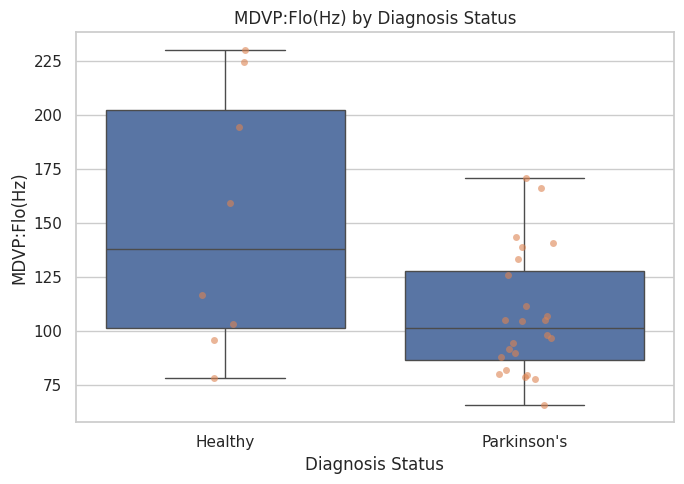

In [19]:
for feature in frequency_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"]
    )
    
    sns.stripplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        alpha=0.6,
        jitter=True
    )
    
    plt.title(f"{feature} by Diagnosis Status")
    plt.xlabel("Diagnosis Status")
    plt.ylabel(feature)
    
    safe_name = feature.replace(":", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"{figures_dir}/frequency_{safe_name}.png", dpi=300)
    plt.show()

### Frequency Feature Analysis

At the patient level, all three frequency-based vocal biomarkers show lower mean values among patients associated with Parkinson’s disease compared with healthy controls. The average fundamental frequency, `MDVP:Fo(Hz)`, is lower in the Parkinson’s group at approximately 144.18 Hz compared with 183.13 Hz in the healthy group. A similar pattern appears for the maximum frequency measure, `MDVP:Fhi(Hz)`, with means of 177.77 Hz and 207.74 Hz, respectively, and for the minimum frequency measure, `MDVP:Flo(Hz)`, with means of 107.21 Hz and 150.18 Hz. Of these features, `MDVP:Flo(Hz)` shows the largest difference in group means, approximately 42.96 Hz lower in the Parkinson’s group, and its boxplot suggests a noticeable downward shift in the distribution. However, the boxplots also show substantial overlap between the diagnosis groups, particularly for `MDVP:Fo(Hz)` and `MDVP:Fhi(Hz)`, along with variation within each group. Therefore, lower pitch-related measurements appear to be associated with Parkinson’s disease in this dataset, but frequency features alone do not appear sufficient to clearly distinguish patients between the two groups.


## 5. Jitter Features: Frequency Instability

Jitter measures short-term variation in vocal frequency. In simpler terms, jitter describes how stable or unstable a person’s pitch is while producing a sustained voice recording.

Higher jitter may indicate greater pitch instability, which may be associated with impaired vocal motor control in Parkinson’s disease.

In [21]:
patient_df.groupby("diagnosis_label")[jitter_features].mean().T

diagnosis_label,Healthy,Parkinson's
MDVP:Jitter(%),0.003613,0.006413
MDVP:Jitter(Abs),0.000022,0.000047
MDVP:RAP,0.001809,0.003436
MDVP:PPQ,0.001973,0.003655
Jitter:DDP,0.005428,0.010307


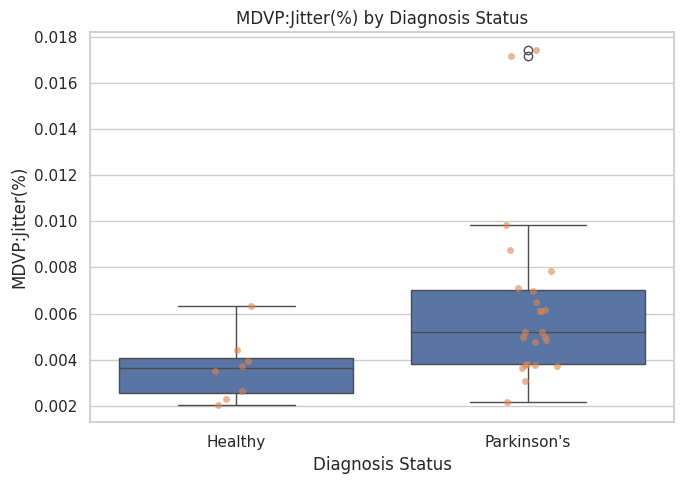

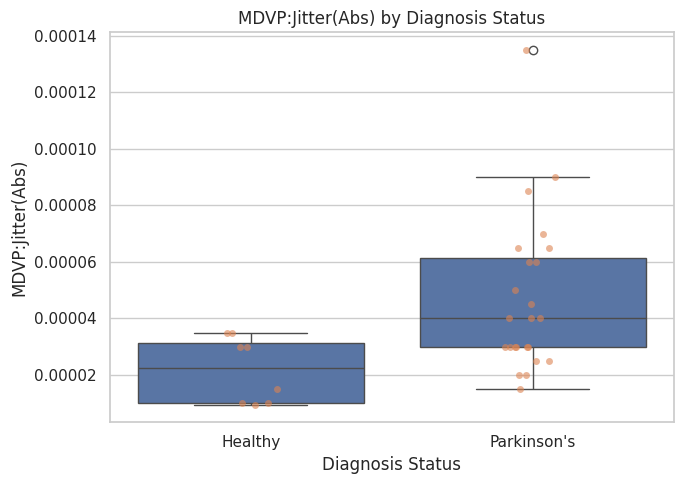

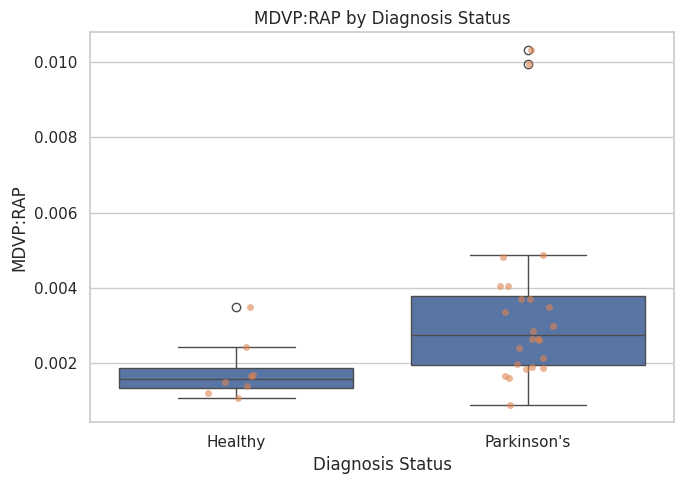

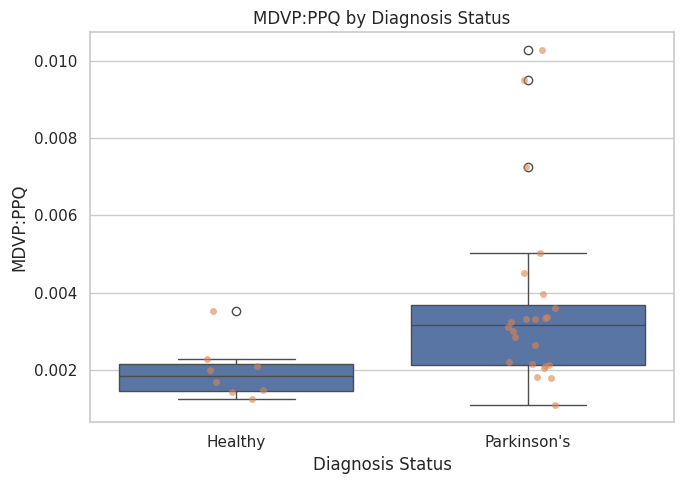

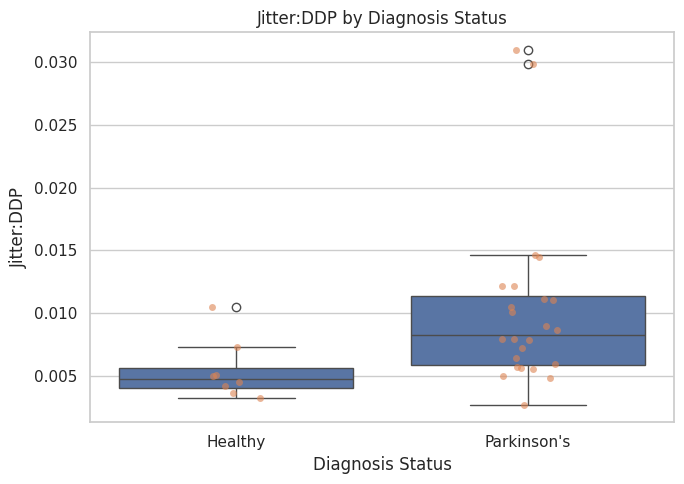

In [22]:
for feature in jitter_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"]
    )
    
    sns.stripplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        alpha=0.6,
        jitter=True
    )
    
    plt.title(f"{feature} by Diagnosis Status")
    plt.xlabel("Diagnosis Status")
    plt.ylabel(feature)
    
    safe_name = feature.replace(":", "_").replace("(", "").replace(")", "").replace("%", "pct")
    plt.tight_layout()
    plt.savefig(f"{figures_dir}/jitter_{safe_name}.png", dpi=300)
    plt.show()

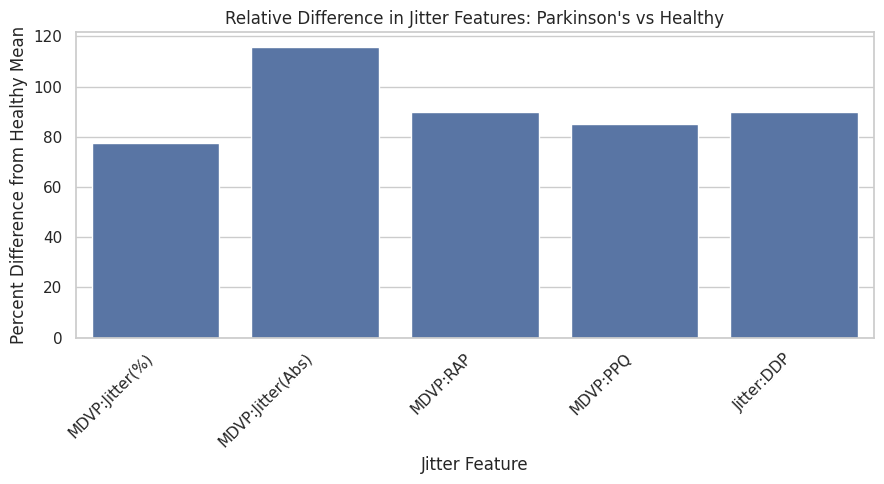

,Healthy,Parkinson's,Percent Difference
MDVP:Jitter(%),0.003613,0.006413,77.477945
MDVP:Jitter(Abs),0.000022,0.000047,115.854823
MDVP:RAP,0.001809,0.003436,89.890616
MDVP:PPQ,0.001973,0.003655,85.297845
Jitter:DDP,0.005428,0.010307,89.890616


In [23]:
jitter_summary = patient_df.groupby("diagnosis_label")[jitter_features].mean().T

jitter_summary.columns = ["Healthy", "Parkinson's"]

jitter_summary["Percent Difference"] = (
    (jitter_summary["Parkinson's"] - jitter_summary["Healthy"]) /
    jitter_summary["Healthy"].abs() *
    100
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=jitter_summary.reset_index(),
    x="index",
    y="Percent Difference"
)

plt.title("Relative Difference in Jitter Features: Parkinson's vs Healthy")
plt.xlabel("Jitter Feature")
plt.ylabel("Percent Difference from Healthy Mean")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{figures_dir}/jitter_percent_differences.png", dpi=300)
plt.show()

jitter_summary

### Jitter Feature Analysis

At the patient level, all five jitter-related vocal biomarkers are higher on average in the Parkinson’s group than in the healthy control group. Jitter measures quantify cycle-to-cycle variation in vocal frequency, so the consistent upward shift across MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, and Jitter:DDP suggests greater frequency instability among the patients associated with Parkinson’s disease in this dataset. The largest relative difference is observed for MDVP:Jitter(Abs), which is approximately 116% higher in the Parkinson’s group. The remaining jitter features are also substantially elevated, ranging from approximately 77% higher for MDVP:Jitter(%) to about 90% higher for MDVP:RAP and Jitter:DDP. The boxplots show that the Parkinson’s group generally has higher medians and greater variability, including several high-value observations, while the healthy group is more tightly concentrated at lower values. However, overlap remains between the groups, meaning that jitter features alone do not provide complete separation. Overall, these results indicate that vocal frequency instability may be a useful group of biomarkers associated with Parkinson’s disease, especially when combined with other voice measurements in later analysis and modeling.

## Shimmer Features: Amplitude Instability

Shimmer measures short-term variation in vocal amplitude, or loudness. Higher shimmer values indicate that the intensity of the voice changes more irregularly during recording.

This section explores whether Parkinson’s patients exhibit greater amplitude instability than healthy patients.

In [24]:
patient_df.groupby("diagnosis_label")[shimmer_features].mean().T

diagnosis_label,Healthy,Parkinson's
MDVP:Shimmer,0.017476,0.031651
MDVP:Shimmer(dB),0.162438,0.299687
Shimmer:APQ3,0.009472,0.016615
Shimmer:APQ5,0.010412,0.019074
MDVP:APQ,0.013254,0.025950
Shimmer:DDA,0.028419,0.049847


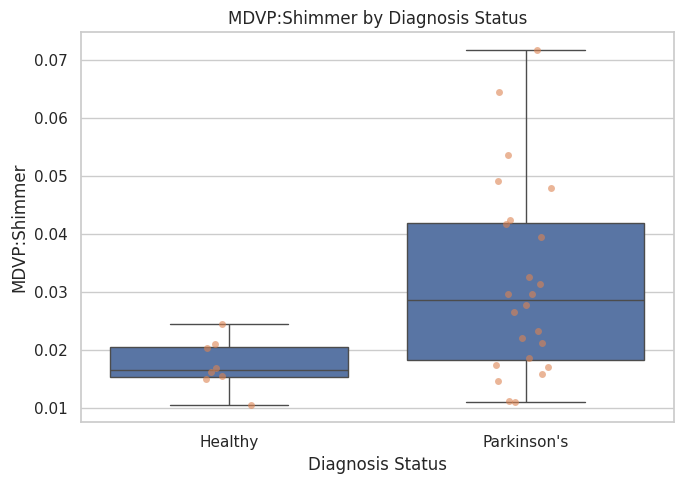

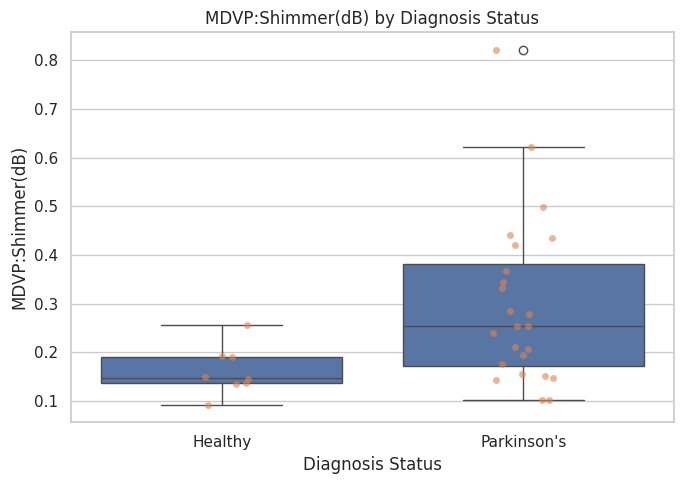

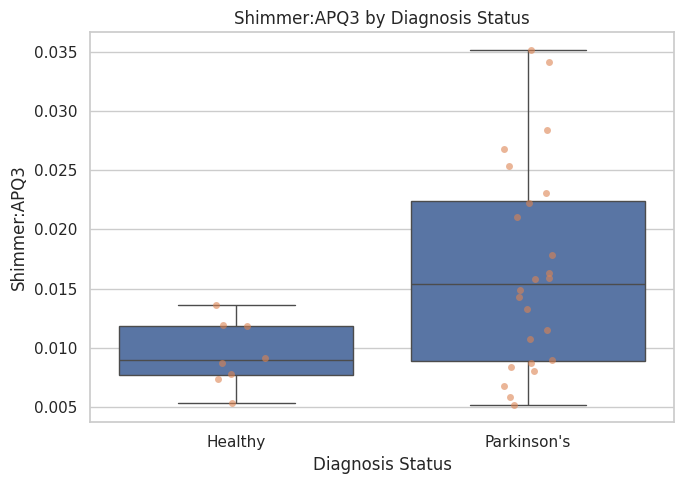

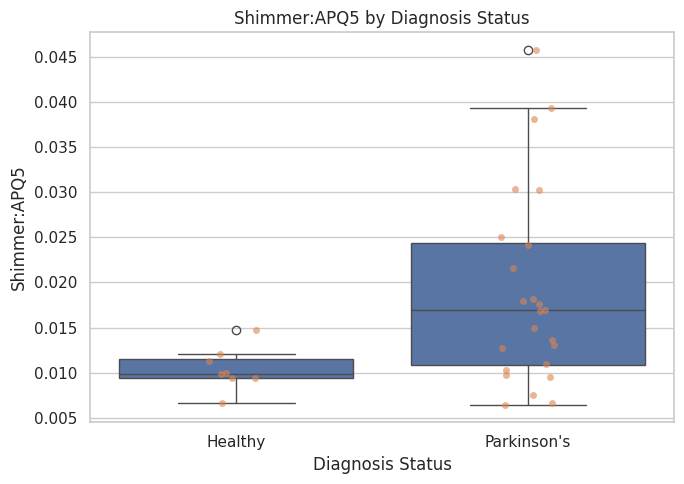

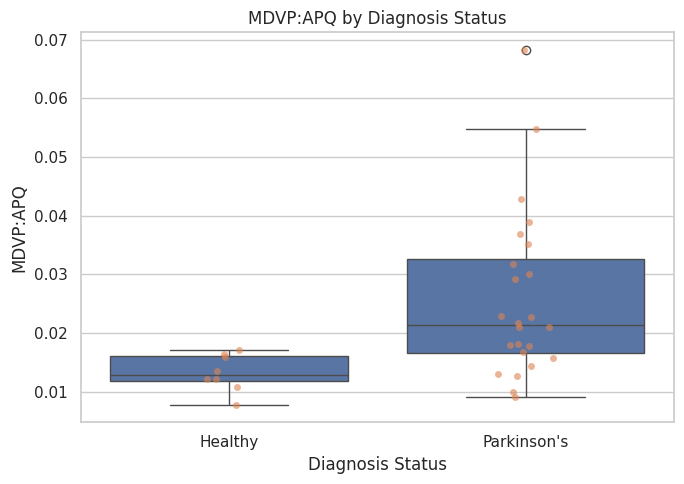

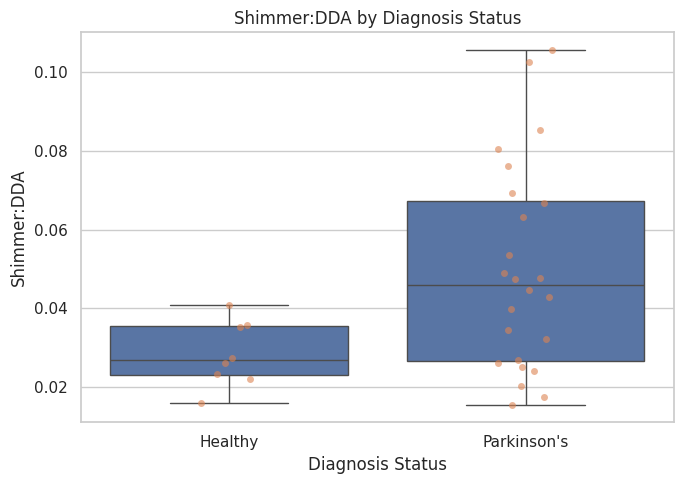

In [25]:
for feature in shimmer_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"]
    )
    
    sns.stripplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        alpha=0.6,
        jitter=True
    )
    
    plt.title(f"{feature} by Diagnosis Status")
    plt.xlabel("Diagnosis Status")
    plt.ylabel(feature)
    
    safe_name = feature.replace(":", "_").replace("(", "").replace(")", "")
    plt.tight_layout()
    plt.savefig(f"{figures_dir}/shimmer_{safe_name}.png", dpi=300)
    plt.show()

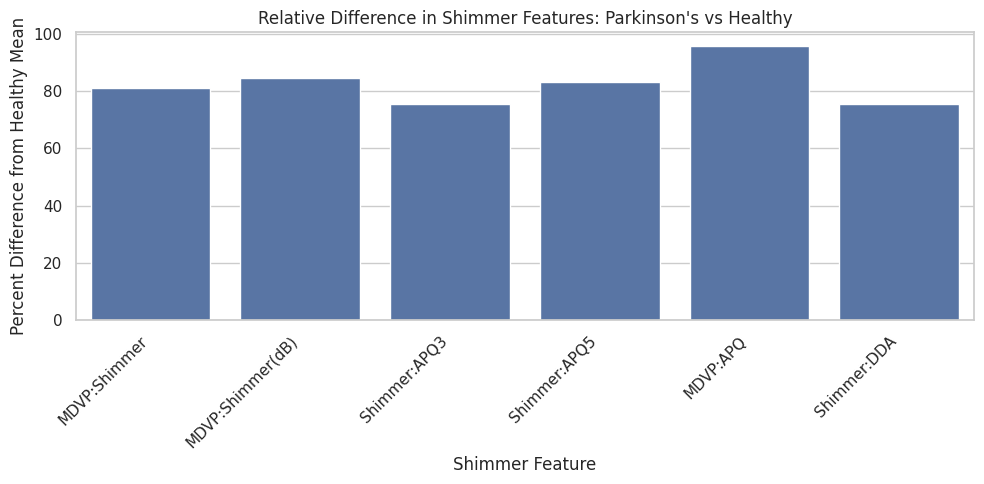

,Healthy,Parkinson's,Percent Difference
MDVP:Shimmer,0.017476,0.031651,81.110078
MDVP:Shimmer(dB),0.162438,0.299687,84.494036
Shimmer:APQ3,0.009472,0.016615,75.418454
Shimmer:APQ5,0.010412,0.019074,83.185274
MDVP:APQ,0.013254,0.025950,95.793643
Shimmer:DDA,0.028419,0.049847,75.402830


In [26]:
shimmer_summary = patient_df.groupby("diagnosis_label")[shimmer_features].mean().T

shimmer_summary.columns = ["Healthy", "Parkinson's"]

shimmer_summary["Percent Difference"] = (
    (shimmer_summary["Parkinson's"] - shimmer_summary["Healthy"]) /
    shimmer_summary["Healthy"].abs() *
    100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=shimmer_summary.reset_index(),
    x="index",
    y="Percent Difference"
)

plt.title("Relative Difference in Shimmer Features: Parkinson's vs Healthy")
plt.xlabel("Shimmer Feature")
plt.ylabel("Percent Difference from Healthy Mean")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{figures_dir}/shimmer_percent_differences.png", dpi=300)
plt.show()

shimmer_summary

### Shimmer Feature Analysis

At the patient level, all six shimmer-related vocal biomarkers are higher on average among patients associated with Parkinson’s disease than among healthy controls. Because shimmer measures variation in vocal amplitude, this consistent pattern suggests greater amplitude instability in the Parkinson’s group within this dataset. The largest relative difference is observed for MDVP:APQ, which is approximately 95.8% higher in the Parkinson’s group, followed by MDVP:Shimmer(dB) at approximately 84.5% higher and Shimmer:APQ5 at approximately 83.2% higher. The boxplots consistently show higher median shimmer values and a wider spread among patients associated with Parkinson’s disease, indicating greater variability within this group as well as several especially high observations. However, some Parkinson’s patients still have shimmer values that overlap with the healthy range, particularly at the lower end of the distributions. These results suggest that measures of vocal amplitude instability may be useful biomarkers associated with Parkinson’s disease, but they should be interpreted alongside other vocal features rather than treated as individually sufficient for distinguishing diagnosis groups.

## 7. Noise Features

Noise-related biomarkers describe how much of the vocal signal is harmonic versus noisy.

- `NHR` = noise-to-harmonics ratio. Higher values indicate relatively more vocal noise.
- `HNR` = harmonics-to-noise ratio. Higher values indicate a cleaner, more harmonic voice signal.

This section explores whether Parkinson’s patients have noisier vocal signals than healthy patients.

In [27]:
patient_df.groupby("diagnosis_label")[noise_features].mean().T

diagnosis_label,Healthy,Parkinson's
NHR,0.010080,0.024513
HNR,24.749312,21.101646


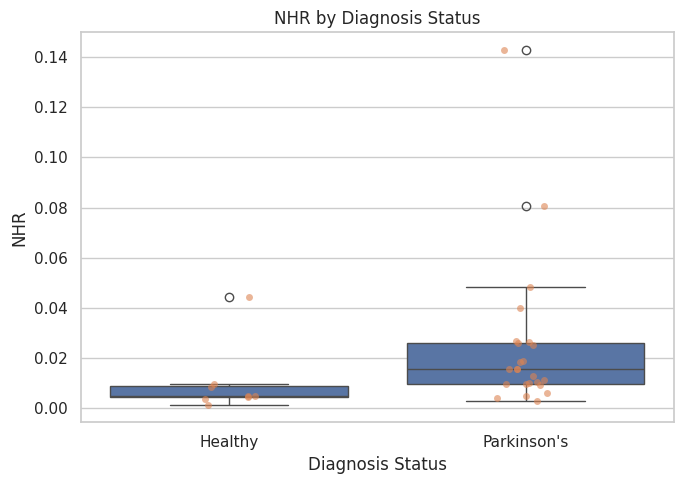

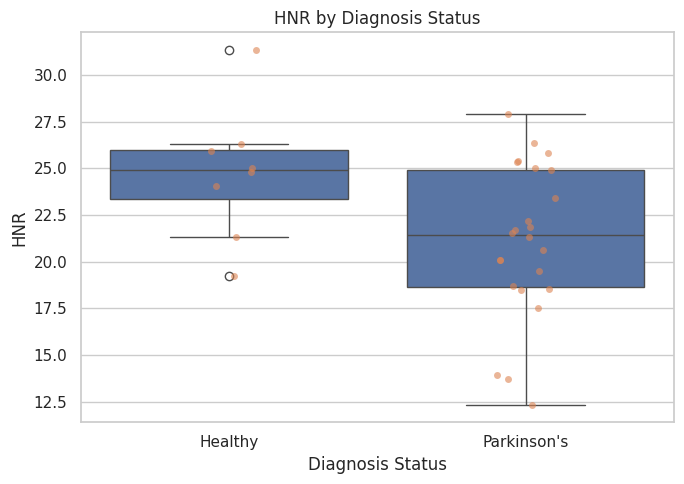

In [28]:
for feature in noise_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"]
    )
    
    sns.stripplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        alpha=0.6,
        jitter=True
    )
    
    plt.title(f"{feature} by Diagnosis Status")
    plt.xlabel("Diagnosis Status")
    plt.ylabel(feature)
    
    plt.tight_layout()
    plt.savefig(f"{figures_dir}/noise_{feature}.png", dpi=300)
    plt.show()

### Noise Feature Analysis

At the patient level, the two noise-related vocal biomarkers show contrasting patterns between the diagnosis groups. Patients associated with Parkinson’s disease have a higher mean NHR value than healthy controls, approximately 0.0245 compared with 0.0101, suggesting a greater proportion of noise relative to harmonic signal in their voice measurements. In contrast, the Parkinson’s group has a lower mean HNR value, approximately 21.10 compared with 24.75 in the healthy group, which is consistent with reduced harmonic clarity. The NHR boxplot shows a more noticeable upward shift for the Parkinson’s group, although it also includes several high-value observations and substantial right-skew, meaning that the higher average is influenced in part by extreme values. The HNR distributions also differ, with the Parkinson’s group generally shifted lower, but there is still considerable overlap between groups. Based on these visualizations, NHR appears to show the stronger group difference, while HNR provides complementary information in the opposite direction. Together, these features suggest that noisier and less harmonically stable voice measurements may be associated with Parkinson’s disease in this dataset, but neither measure alone clearly separates all patients.

## Nonlinear Vocal Complexity Features

Nonlinear biomarkers measure more complex forms of vocal irregularity that may not be fully described by basic pitch or amplitude measurements.

The features examined here are:

- `RPDE`
- `DFA`
- `spread1`
- `spread2`
- `D2`
- `PPE`

These features are particularly interesting because they attempt to capture irregular and complex changes in vocal behavior associated with Parkinson’s disease.

In [29]:
patient_df.groupby("diagnosis_label")[nonlinear_features].mean().T

diagnosis_label,Healthy,Parkinson's
RPDE,0.439898,0.520414
DFA,0.693143,0.725415
spread1,-6.809360,-5.341969
spread2,0.161294,0.245297
D2,2.144119,2.430038
PPE,0.120151,0.233099


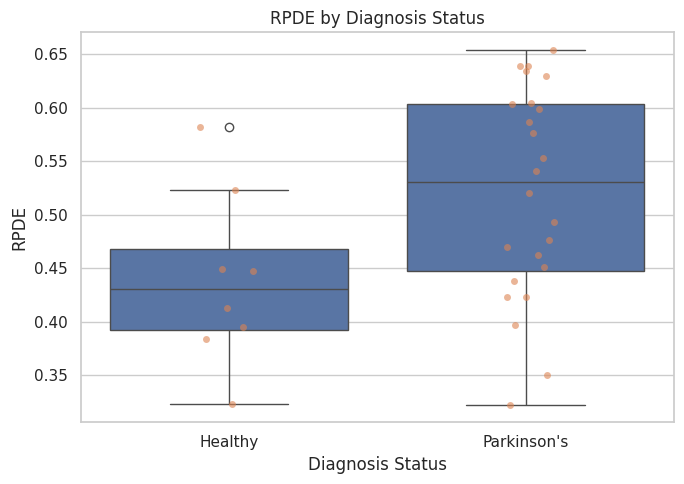

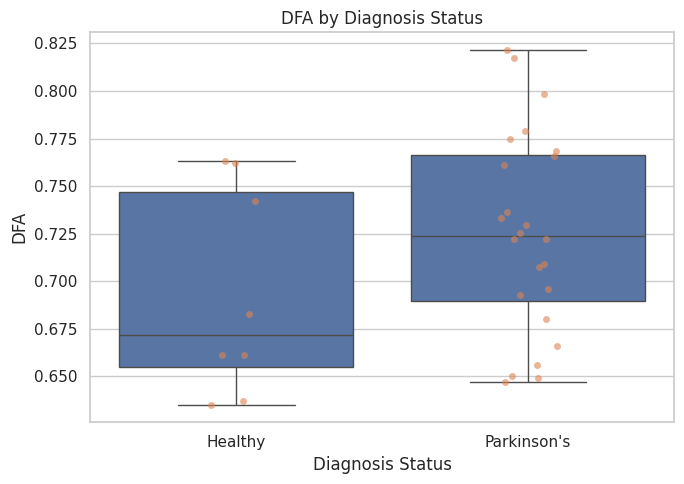

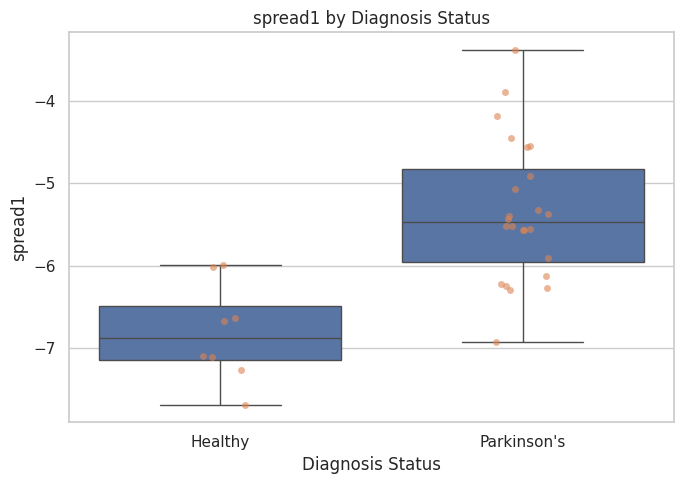

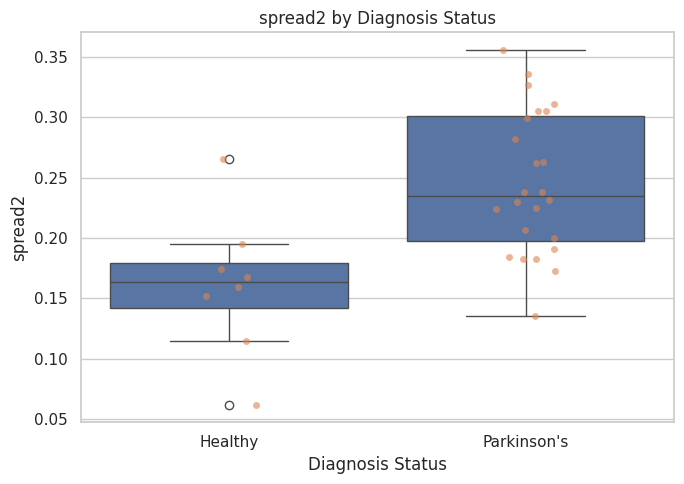

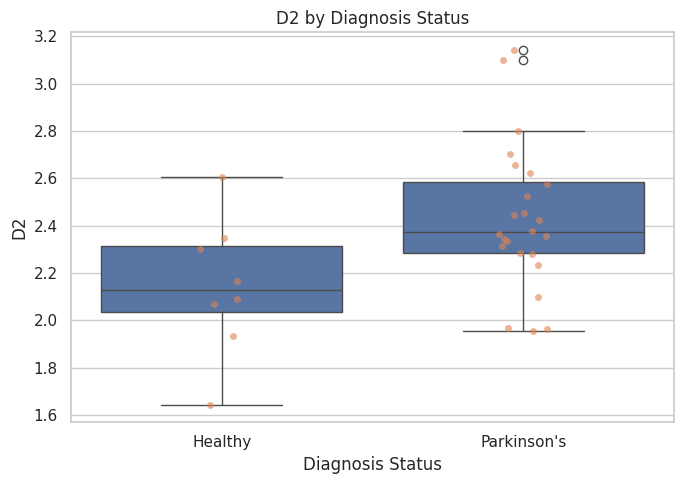

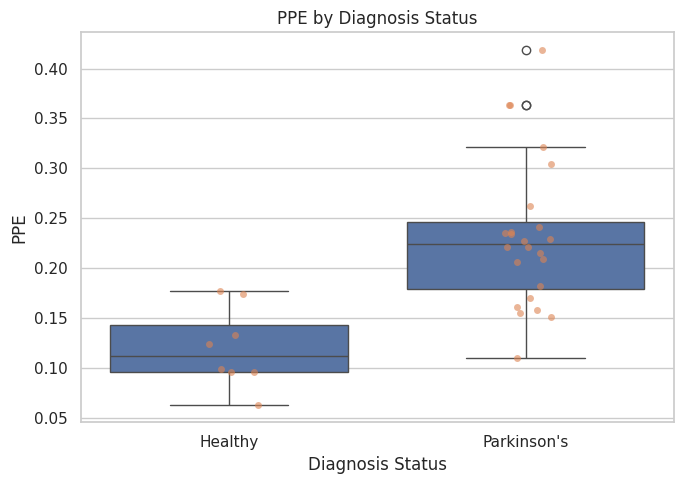

In [30]:
for feature in nonlinear_features:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"]
    )
    
    sns.stripplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        alpha=0.6,
        jitter=True
    )
    
    plt.title(f"{feature} by Diagnosis Status")
    plt.xlabel("Diagnosis Status")
    plt.ylabel(feature)
    
    plt.tight_layout()
    plt.savefig(f"{figures_dir}/nonlinear_{feature}.png", dpi=300)
    plt.show()

### Nonlinear Feature Analysis

At the patient level, the nonlinear vocal biomarkers generally show higher values among patients associated with Parkinson’s disease than among healthy controls. The strongest group differences are visible for `PPE` and `spread1`. Mean `PPE` is approximately 0.233 in the Parkinson’s group compared with 0.120 in the healthy group, representing a substantial increase, and the boxplot shows relatively limited overlap between the central portions of the two distributions. The `spread1` feature also shows a clear shift, with Parkinson’s patients having less negative values on average than healthy controls (`-5.34` compared with `-6.81`), and the boxplot suggests stronger visual separation than many of the earlier frequency, jitter, and shimmer measurements. `spread2` also differs notably between groups, with higher average values in the Parkinson’s group, while `RPDE` and `D2` show smaller but visible upward shifts. In contrast, `DFA` exhibits considerable overlap and appears less useful as an individual separating feature in this sample. Overall, the nonlinear measures, particularly `PPE`, `spread1`, and possibly `spread2`, appear valuable for later machine learning analysis because they capture voice signal patterns that may complement traditional frequency, jitter, shimmer, and noise biomarkers. These findings remain exploratory and should be validated using patient-aware modeling because the dataset contains a small number of patients.


## 9. Correlation Analysis

Many biomarkers in this dataset measure related forms of vocal instability. For example, multiple jitter variables measure frequency variation, while multiple shimmer variables measure amplitude variation.

This section explores whether features are highly correlated with each other and whether some variables may contain redundant information.

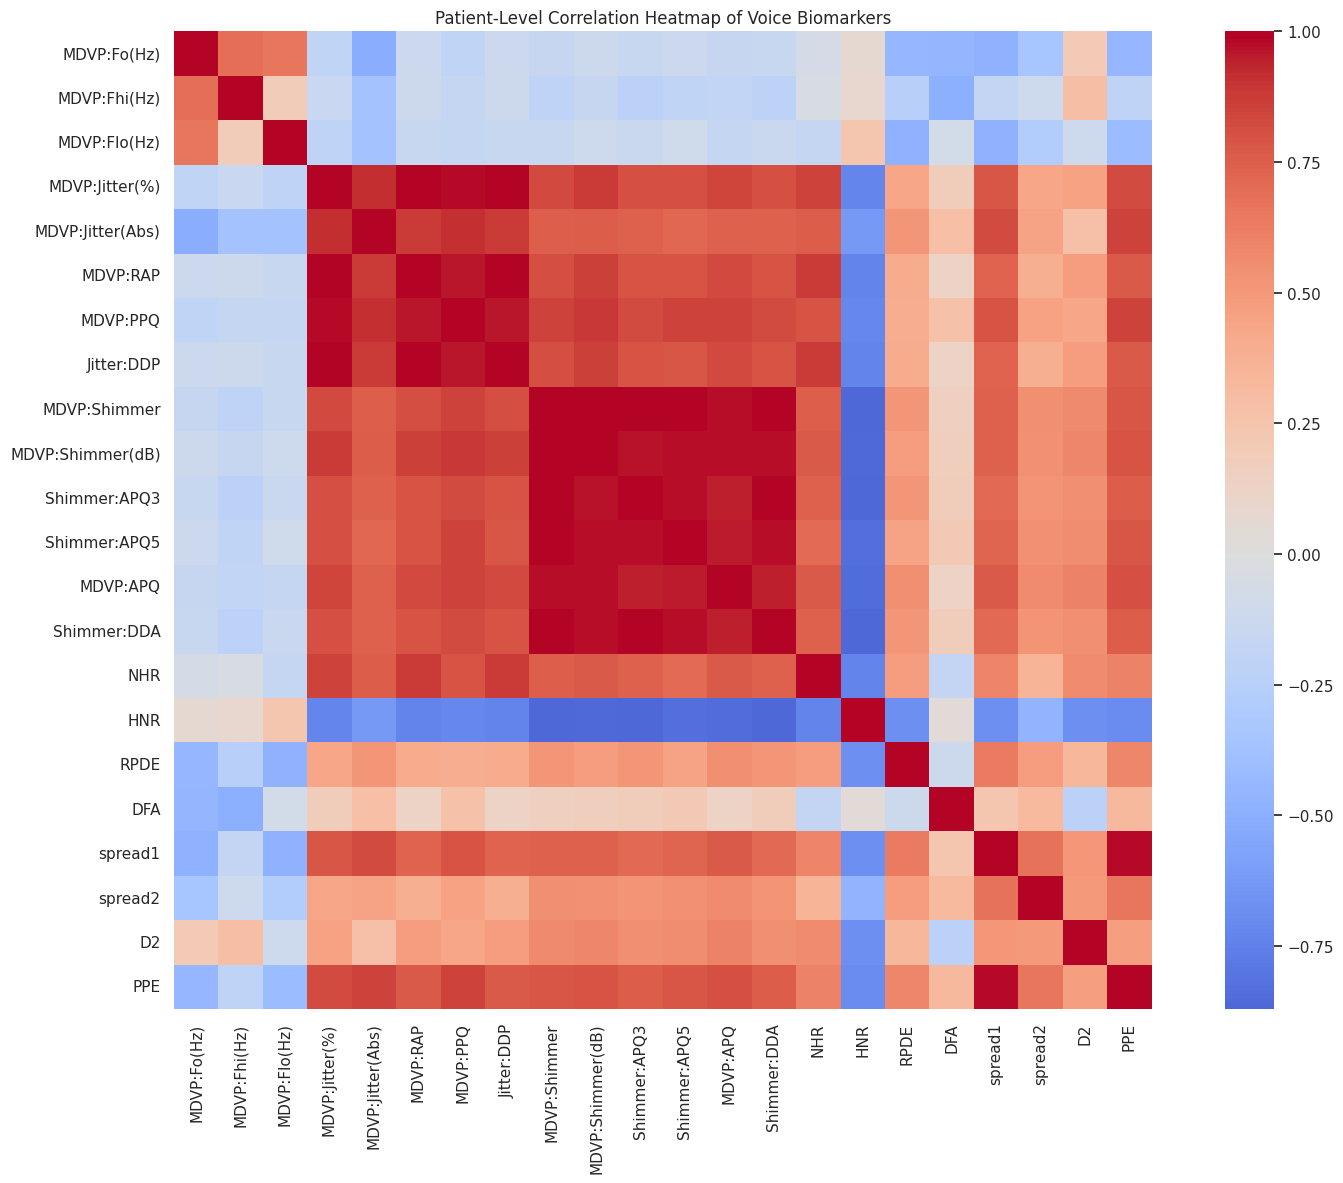

In [31]:
correlation_matrix = patient_df[all_feature_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Patient-Level Correlation Heatmap of Voice Biomarkers")

plt.tight_layout()
plt.savefig(f"{figures_dir}/biomarker_correlation_heatmap.png", dpi=300)
plt.show()

In [32]:
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_correlation_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs["Correlation"].abs() >= 0.80
].sort_values("Correlation", ascending=False)

high_correlation_pairs

,Feature 1,Feature 2,Correlation
233,Shimmer:APQ3,Shimmer:DDA,1.000000
117,MDVP:RAP,Jitter:DDP,1.000000
186,MDVP:Shimmer,Shimmer:APQ3,0.993857
189,MDVP:Shimmer,Shimmer:DDA,0.993856
71,MDVP:Jitter(%),MDVP:RAP,0.989271
73,MDVP:Jitter(%),Jitter:DDP,0.989229
185,MDVP:Shimmer,MDVP:Shimmer(dB),0.986602
187,MDVP:Shimmer,Shimmer:APQ5,0.985830
72,MDVP:Jitter(%),MDVP:PPQ,0.980332
417,spread1,PPE,0.978923


In [33]:
correlations_with_status = (
    patient_df[all_feature_columns + ["status"]]
    .corr()["status"]
    .drop("status")
    .sort_values()
)

correlations_with_status

MDVP:Flo(Hz)       -0.447681
MDVP:Fo(Hz)        -0.409199
HNR                -0.378220
MDVP:Fhi(Hz)       -0.203116
NHR                 0.228130
DFA                 0.262401
MDVP:RAP            0.333646
Jitter:DDP          0.333719
MDVP:Jitter(%)      0.344766
MDVP:PPQ            0.345776
RPDE                0.355658
MDVP:Shimmer(dB)    0.370051
Shimmer:APQ5        0.374631
Shimmer:DDA         0.380837
Shimmer:APQ3        0.380865
D2                  0.388583
MDVP:Shimmer        0.397004
MDVP:APQ            0.406532
MDVP:Jitter(Abs)    0.410971
spread2             0.536529
PPE                 0.593508
spread1             0.634127
Name: status, dtype: float64

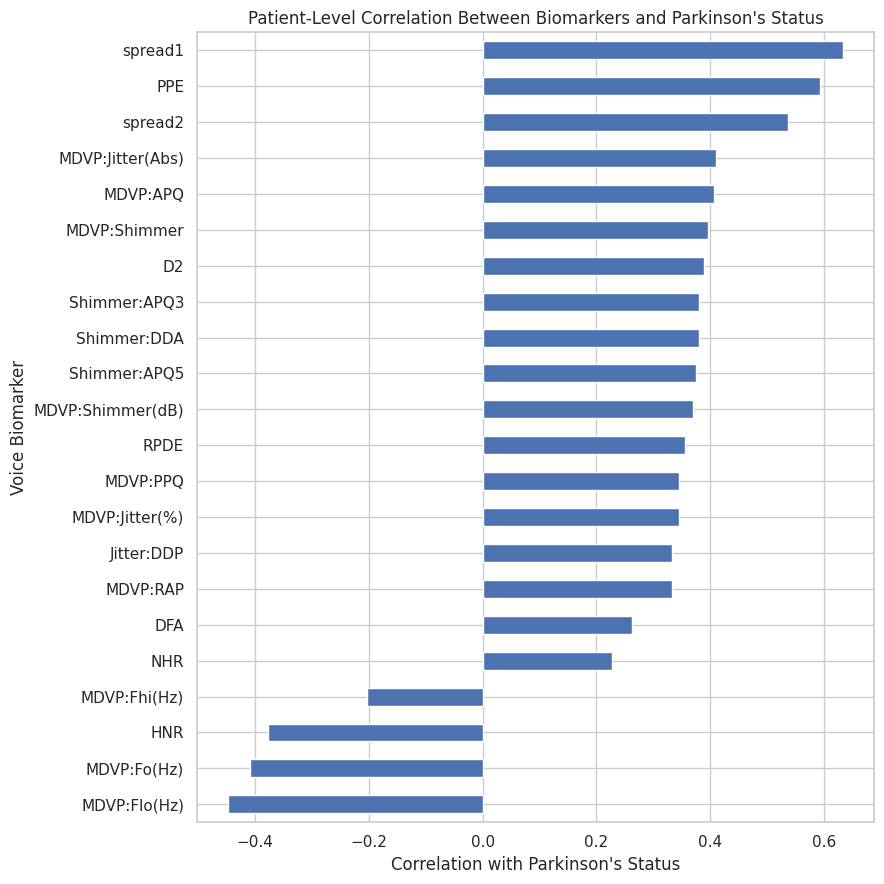

In [34]:
plt.figure(figsize=(9, 9))

correlations_with_status.plot(kind="barh")

plt.title("Patient-Level Correlation Between Biomarkers and Parkinson's Status")
plt.xlabel("Correlation with Parkinson's Status")
plt.ylabel("Voice Biomarker")

plt.tight_layout()
plt.savefig(f"{figures_dir}/correlation_with_status.png", dpi=300)
plt.show()

### Correlation Analysis Interpretation

At the patient level, the nonlinear biomarkers show the strongest positive correlations with Parkinson’s status. `spread1` has the strongest positive relationship (`r = 0.634`), followed by `PPE` (`r = 0.594`) and `spread2` (`r = 0.537`), supporting the earlier visual observation that these features provide some of the clearest group differences in this dataset. Among the traditional vocal measurements, `MDVP:Jitter(Abs)` (`r = 0.411`) and `MDVP:APQ` (`r = 0.407`) show the strongest positive correlations with Parkinson’s status, while several additional shimmer and jitter measures demonstrate moderate positive relationships. The strongest negative correlations are observed for the frequency-related biomarkers `MDVP:Flo(Hz)` (`r = -0.448`) and `MDVP:Fo(Hz)` (`r = -0.409`), followed by `HNR` (`r = -0.378`), indicating that lower pitch-related measurements and lower harmonic-to-noise ratios are associated with the Parkinson’s group in this patient-level summary. Although `NHR` was substantially higher on average in the Parkinson’s group, its correlation with status is comparatively weaker (`r = 0.228`), likely reflecting the wide spread and high-value observations visible in its distribution.

The correlation heatmap also reveals substantial relationships among the vocal biomarkers themselves. Jitter measures are strongly intercorrelated, including `MDVP:Jitter(%)` and `MDVP:Jitter(Abs)` (`r = 0.915`) as well as strong relationships among `MDVP:Jitter(Abs)`, `MDVP:RAP`, `MDVP:PPQ`, and `Jitter:DDP`. Similarly, shimmer measures are highly correlated with one another, with `Shimmer:APQ3` and `MDVP:APQ` showing one of the strongest feature-to-feature correlations (`r = 0.944`). Strong relationships are also present across jitter, shimmer, and noise measurements, while multiple shimmer measures are strongly negatively correlated with `HNR`. This pattern suggests that several variables may capture overlapping aspects of vocal irregularity. In later machine learning analysis, this redundancy should be considered through techniques such as feature selection, regularization, or dimension reduction to reduce unnecessary duplication and improve model interpretability. Finally, these correlations identify associations within a small exploratory dataset and do not establish that any vocal biomarker causes Parkinson’s disease or independently determines diagnosis.


## Distribution Comparisons for the Most Associated Biomarkers

This section selects the biomarkers with the strongest absolute correlations with Parkinson’s status and compares their patient-level distributions between healthy and Parkinson’s groups.

In [35]:
top_features = (
    correlations_with_status
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

top_features

['spread1',
 'PPE',
 'spread2',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(Abs)',
 'MDVP:Fo(Hz)']

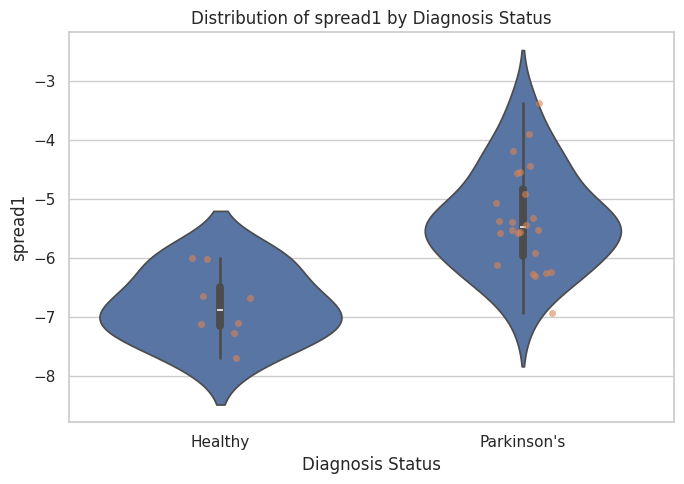

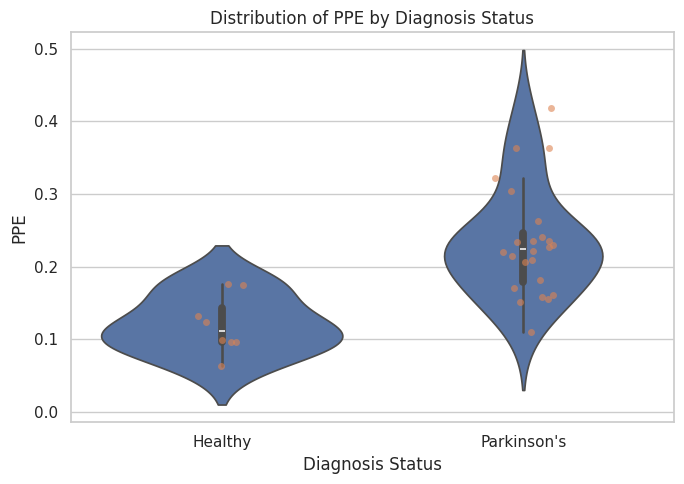

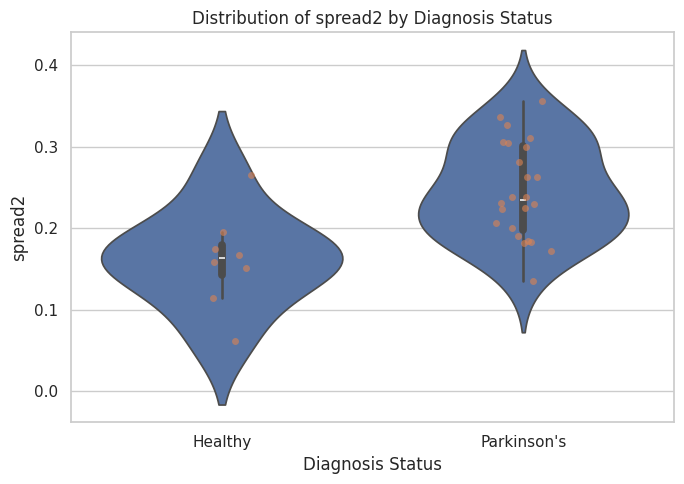

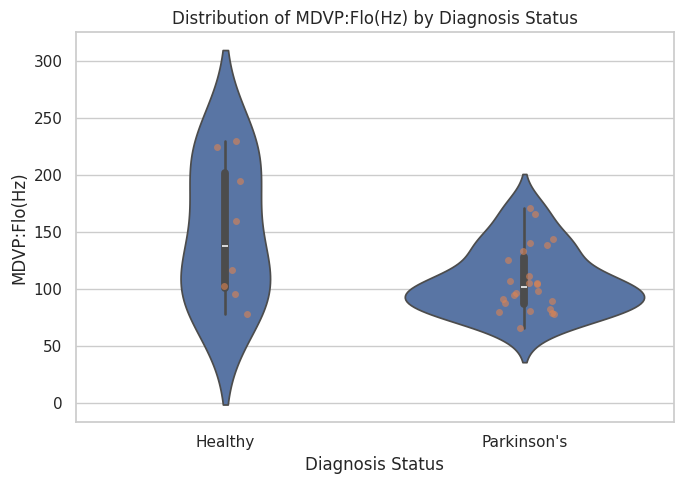

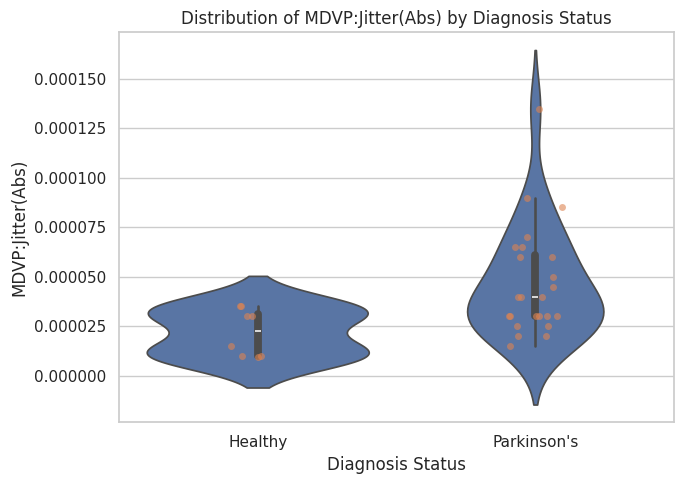

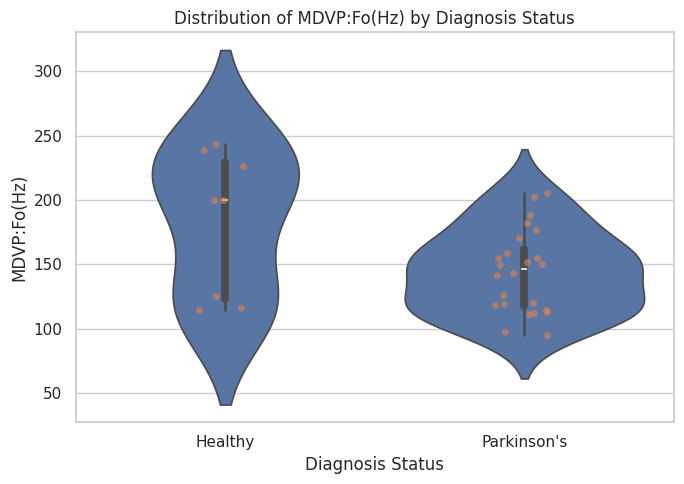

In [36]:
for feature in top_features:
    plt.figure(figsize=(7, 5))
    
    sns.violinplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        inner="box"
    )
    
    sns.stripplot(
        data=patient_df,
        x="diagnosis_label",
        y=feature,
        order=["Healthy", "Parkinson's"],
        alpha=0.6,
        jitter=True
    )
    
    plt.title(f"Distribution of {feature} by Diagnosis Status")
    plt.xlabel("Diagnosis Status")
    plt.ylabel(feature)
    
    safe_name = feature.replace(":", "_").replace("(", "").replace(")", "").replace("%", "pct")
    plt.tight_layout()
    plt.savefig(f"{figures_dir}/top_feature_{safe_name}.png", dpi=300)
    plt.show()

### Key Biomarker Distribution Analysis

The distributions of the top patient-level biomarkers show that the strongest visual separation between the diagnosis groups is provided by the nonlinear features spread1 and PPE. Patients associated with Parkinson’s disease generally have higher, or less negative, spread1 values and substantially higher PPE values than healthy controls, with relatively limited overlap in the central portions of the distributions. spread2 also shows an upward shift in the Parkinson’s group, although its distributions overlap more than those of spread1 and PPE. Among the traditional vocal measurements, MDVP:Flo(Hz) and MDVP:Fo(Hz) are generally lower in the Parkinson’s group, but both frequency features show considerable overlap, particularly because healthy patients display a wide range of values. MDVP:Jitter(Abs) is generally higher in the Parkinson’s group and may contribute useful information about vocal frequency instability, although several Parkinson’s observations remain within the healthy range. Overall, the most promising variables for later classification appear to be a mixture of nonlinear biomarkers, particularly spread1 and PPE, along with selected traditional measures such as MDVP:Flo(Hz) and MDVP:Jitter(Abs). However, no individual feature completely separates the groups, supporting the use of multivariable machine learning models evaluated with patient-aware splitting.

## Principal Component Analysis Visualization

Principal Component Analysis (PCA) reduces the full set of voice biomarkers into two dimensions for visualization.

Before applying PCA, all biomarkers are standardized because the features use different measurement scales. For example, frequency values are measured in Hz, while jitter and shimmer values are much smaller numerical measurements.

This analysis is exploratory. PCA does not build a predictive model, but it can help determine whether healthy and Parkinson’s patients display visible structure in the combined biomarker space.

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_patient = patient_df[all_feature_columns]
y_patient = patient_df["status"]

scaler = StandardScaler()
X_patient_scaled = scaler.fit_transform(X_patient)

pca = PCA(n_components=2)
X_patient_pca = pca.fit_transform(X_patient_scaled)

pca_df = pd.DataFrame({
    "PC1": X_patient_pca[:, 0],
    "PC2": X_patient_pca[:, 1],
    "diagnosis_label": patient_df["diagnosis_label"],
    "patient_id": patient_df["patient_id"]
})

pca_df.head()

,PC1,PC2,diagnosis_label,patient_id
0,5.177513,-1.479739,Parkinson's,S01
1,0.175047,-2.695970,Parkinson's,S02
2,-1.972865,-0.589934,Parkinson's,S04
3,2.774493,0.080935,Parkinson's,S05
4,-1.796547,-0.181599,Parkinson's,S06


In [38]:
explained_variance = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Explained Variance Percentage": pca.explained_variance_ratio_ * 100
})

explained_variance

,Principal Component,Explained Variance Ratio,Explained Variance Percentage
0,PC1,0.627648,62.764825
1,PC2,0.125521,12.552111


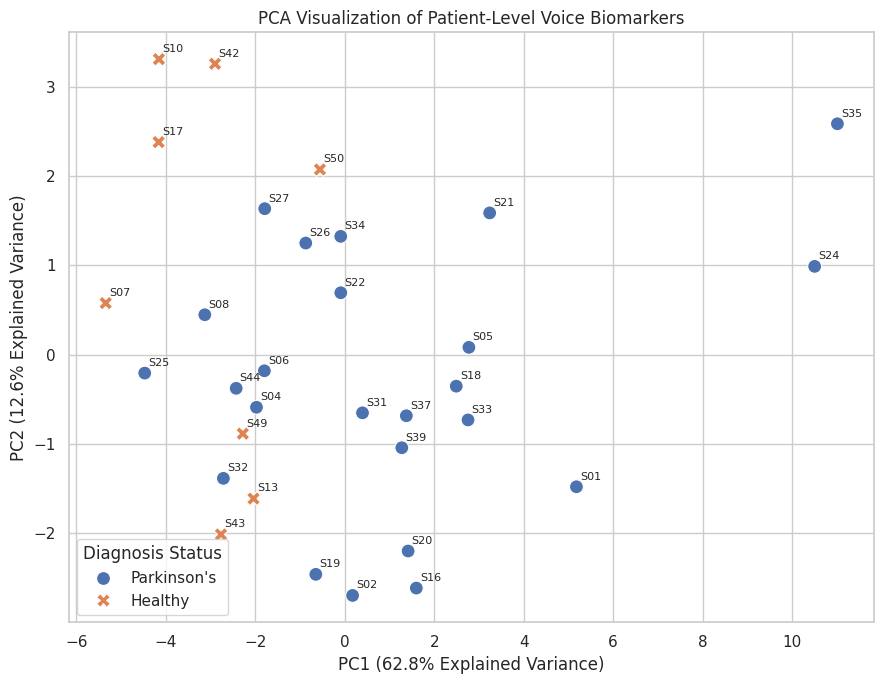

In [39]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="diagnosis_label",
    style="diagnosis_label",
    s=100
)

for _, row in pca_df.iterrows():
    plt.text(
        row["PC1"] + 0.08,
        row["PC2"] + 0.08,
        row["patient_id"],
        fontsize=8
    )

plt.title("PCA Visualization of Patient-Level Voice Biomarkers")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Explained Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Explained Variance)")
plt.legend(title="Diagnosis Status")

plt.tight_layout()
plt.savefig(f"{figures_dir}/patient_level_pca.png", dpi=300)
plt.show()

In [40]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=all_feature_columns,
    columns=["PC1", "PC2"]
)

pca_loadings["PC1 Absolute Contribution"] = pca_loadings["PC1"].abs()
pca_loadings["PC2 Absolute Contribution"] = pca_loadings["PC2"].abs()

pca_loadings.sort_values("PC1 Absolute Contribution", ascending=False).head(10)

,PC1,PC2,PC1 Absolute Contribution,PC2 Absolute Contribution
MDVP:Shimmer(dB),0.258002,0.090627,0.258002,0.090627
MDVP:Shimmer,0.256567,0.065789,0.256567,0.065789
MDVP:APQ,0.256092,0.071008,0.256092,0.071008
Shimmer:APQ3,0.252219,0.063314,0.252219,0.063314
Shimmer:DDA,0.252216,0.063367,0.252216,0.063367
MDVP:PPQ,0.250839,0.018178,0.250839,0.018178
Shimmer:APQ5,0.250481,0.073678,0.250481,0.073678
MDVP:Jitter(%),0.250408,0.032210,0.250408,0.032210
MDVP:RAP,0.245255,0.076389,0.245255,0.076389
Jitter:DDP,0.245251,0.076408,0.245251,0.076408


## PCA Interpretation

The first two principal components explain approximately 75.3% of the total variation in the patient-level vocal biomarker data, with PC1 accounting for 62.8% and PC2 accounting for 12.6%. The PCA visualization shows some visible structure by diagnosis status: healthy controls are concentrated primarily on the negative side of PC1, while patients associated with Parkinson’s disease are distributed more broadly and include most of the patients with positive PC1 values. However, the groups are not completely separated, since several Parkinson’s patients appear in the same region of the plot as healthy controls. The available loading results indicate that PC1 is influenced strongly by multiple shimmer and jitter biomarkers, including `MDVP:Shimmer(dB)`, `MDVP:Shimmer`, `MDVP:APQ`, `Shimmer:APQ3`, `Shimmer:DDA`, `MDVP:PPQ`, `MDVP:Jitter(%)`, `MDVP:RAP`, and `Jitter:DDP`. This suggests that the largest source of variation across patients is related to combined vocal amplitude and frequency instability. Because the displayed output does not identify the strongest PC2 loadings, interpretation of the second component should remain limited to its contribution to the visualization. Overall, the partial clustering seen in the PCA plot suggests that the vocal biomarkers contain meaningful multivariable structure associated with Parkinson’s status, while the remaining overlap indicates that classification will require careful evaluation rather than relying on visual separation alone. Later modeling should continue to use patient-aware splitting to avoid leakage from repeated recordings.


## 12. Effect Size Analysis

Visual differences between groups are useful, but effect sizes provide a numerical estimate of how strongly each biomarker differs between healthy and Parkinson’s patients.

Cohen’s d is used here as a descriptive measure of standardized group difference:

- Values near `0` indicate little difference.
- Larger absolute values indicate stronger separation between groups.

Because the dataset is small and the extracted patient count differs slightly from the documentation, these results should be interpreted cautiously as exploratory evidence rather than clinical proof.

In [41]:
def cohens_d(group_1, group_2):
    n1 = len(group_1)
    n2 = len(group_2)
    
    variance_1 = group_1.var(ddof=1)
    variance_2 = group_2.var(ddof=1)
    
    pooled_std = np.sqrt(
        ((n1 - 1) * variance_1 + (n2 - 1) * variance_2) /
        (n1 + n2 - 2)
    )
    
    return (group_2.mean() - group_1.mean()) / pooled_std


healthy_patients = patient_df[patient_df["status"] == 0]
parkinsons_patients = patient_df[patient_df["status"] == 1]

effect_sizes = []

for feature in all_feature_columns:
    d = cohens_d(
        healthy_patients[feature],
        parkinsons_patients[feature]
    )
    
    effect_sizes.append({
        "Feature": feature,
        "Cohens_d": d,
        "Absolute_Effect_Size": abs(d)
    })

effect_sizes_df = (
    pd.DataFrame(effect_sizes)
    .sort_values("Absolute_Effect_Size", ascending=False)
)

effect_sizes_df

,Feature,Cohens_d,Absolute_Effect_Size
18,spread1,1.833805,1.833805
21,PPE,1.648955,1.648955
19,spread2,1.421664,1.421664
2,MDVP:Flo(Hz),-1.119497,1.119497
4,MDVP:Jitter(Abs),1.008020,1.008020
0,MDVP:Fo(Hz),-1.002795,1.002795
12,MDVP:APQ,0.994962,0.994962
8,MDVP:Shimmer,0.967217,0.967217
20,D2,0.943006,0.943006
10,Shimmer:APQ3,0.921058,0.921058


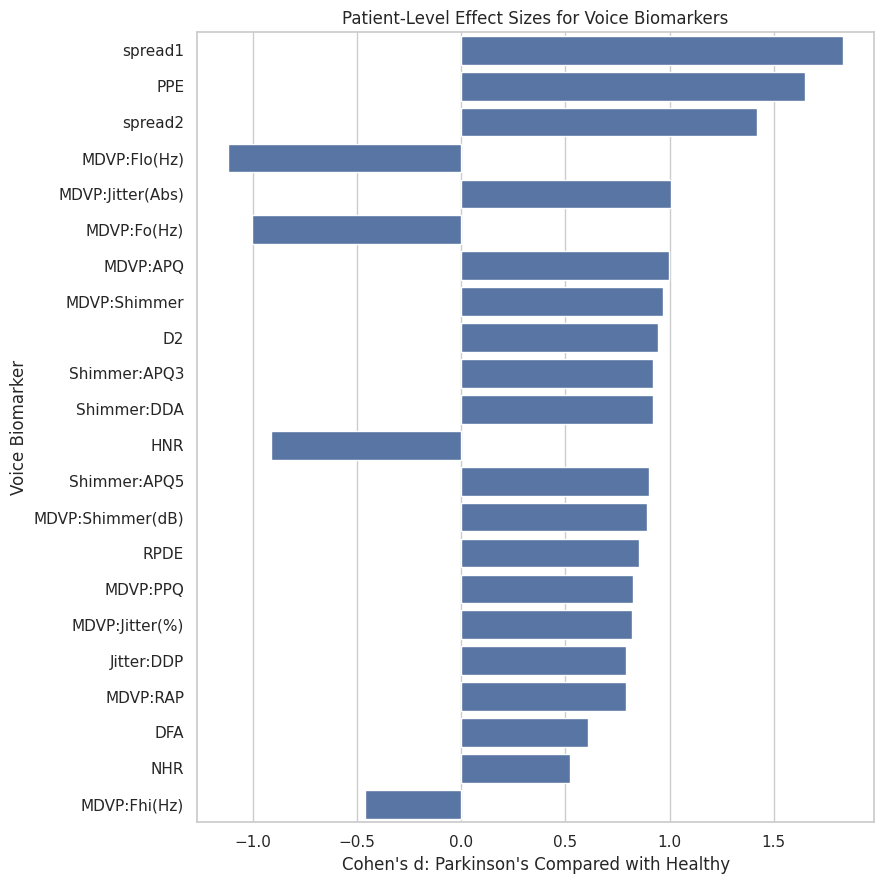

In [42]:
plt.figure(figsize=(9, 9))

sns.barplot(
    data=effect_sizes_df,
    x="Cohens_d",
    y="Feature"
)

plt.title("Patient-Level Effect Sizes for Voice Biomarkers")
plt.xlabel("Cohen's d: Parkinson's Compared with Healthy")
plt.ylabel("Voice Biomarker")

plt.tight_layout()
plt.savefig(f"{figures_dir}/effect_sizes.png", dpi=300)
plt.show()

## Effect Size Interpretation

The patient-level effect size analysis confirms that the largest differences between the diagnosis groups are concentrated in the nonlinear vocal biomarkers. spread1 shows the largest absolute effect size (d = 1.83), followed by PPE (d = 1.65) and spread2 (d = 1.42), with all three having higher values among patients associated with Parkinson’s disease. These results are consistent with the earlier violin plots and correlation analysis, where the nonlinear features showed some of the clearest group-level separation and strongest positive relationships with Parkinson’s status. Several traditional voice measurements also demonstrate large effects. The frequency features MDVP:Flo(Hz) (d = -1.12) and MDVP:Fo(Hz) (d = -1.00) are lower among Parkinson’s patients, while MDVP:Jitter(Abs) (d = 1.01), MDVP:APQ (d = 0.99), and MDVP:Shimmer (d = 0.97) are higher in this group. HNR also shows a notable negative effect (d = -0.91), reflecting lower harmonic-to-noise values among patients associated with Parkinson’s disease. Overall, the strongest effects are not limited to one type of measurement; rather, they include nonlinear features, pitch-related frequency measures, jitter, shimmer, and harmonic quality. This suggests that later classification models may benefit from combining complementary biomarker groups, while also accounting for the strong correlations and possible redundancy among related jitter and shimmer variables. Because these effect sizes were calculated from a small patient-level sample, they should be treated as exploratory evidence of association rather than definitive estimates of diagnostic importance.

## Exploratory Data Analysis Summary

### Dataset Structure

The dataset contains 195 biomedical voice recordings with vocal biomarkers associated with Parkinson’s disease. These recordings do not represent 195 independent patients; instead, multiple measurements were collected from each extracted patient identifier. After extracting patient IDs from the `name` field, 32 unique subject labels were identified, although the UCI documentation reports 31 individuals. This discrepancy is documented as a limitation of the available subject labeling. Because repeated recordings from the same patient may share individual-specific voice characteristics, later machine learning analysis must use patient-aware validation so that recordings from the same patient are not included in both training and testing data.

### Class Distribution

At the recording level, the dataset is imbalanced, with 147 recordings associated with Parkinson’s disease and 48 recordings from healthy controls, representing approximately 75.4% and 24.6% of all observations, respectively. The patient-level summary shows a similar imbalance: 24 of the 32 extracted patient identifiers are associated with Parkinson’s disease, while 8 are healthy controls, representing 75.0% and 25.0% of the extracted subjects. Nearly all patients contribute six recordings, while three Parkinson’s patients contribute seven recordings. This relatively balanced recording structure prevents any single patient from dominating the dataset, but the class imbalance and small number of patients remain important limitations for later modeling and evaluation.

### Biomarker Findings

The frequency-related vocal biomarkers show generally lower values among patients associated with Parkinson’s disease. Mean values for `MDVP:Fo(Hz)`, `MDVP:Fhi(Hz)`, and `MDVP:Flo(Hz)` are all lower in the Parkinson’s group, with `MDVP:Flo(Hz)` showing the largest visible and numerical group difference among the pitch-related features. However, the distributions of the frequency measures still overlap, indicating that pitch-related biomarkers alone are unlikely to clearly distinguish all patients.

The jitter features show a consistent pattern of higher values among patients associated with Parkinson’s disease. All five jitter measurements are elevated in the Parkinson’s group, with `MDVP:Jitter(Abs)` showing the largest relative difference at approximately 116% higher than the healthy mean. Since jitter measures variation in vocal frequency, these findings suggest greater frequency instability in the Parkinson’s group. Although the distributions overlap, the repeated upward shift across the entire jitter feature group indicates that these biomarkers may contribute useful information in a multivariable model.

A similar pattern is observed for the shimmer features, which measure variation in vocal amplitude. All shimmer-related biomarkers are higher on average among patients associated with Parkinson’s disease, with `MDVP:APQ` showing the largest relative difference at approximately 96% higher than the healthy mean. The Parkinson’s group also displays wider distributions and several high-value observations across the shimmer measurements. These findings suggest that greater amplitude instability is associated with Parkinson’s disease in this dataset, although shimmer measures alone do not completely separate the groups.

The noise-related biomarkers also differ between diagnosis groups. Patients associated with Parkinson’s disease show higher `NHR` values and lower `HNR` values than healthy controls, which is consistent with noisier and less harmonically clear voice measurements. `NHR` shows a substantial relative increase in the Parkinson’s group, although its distribution is influenced by high-value observations. `HNR` provides complementary information in the opposite direction, with generally lower values among Parkinson’s patients. Both measures may be useful when combined with other biomarkers, but neither individually provides complete separation.

The nonlinear features provide some of the clearest patient-level differences in the exploratory analysis. In particular, `spread1`, `PPE`, and `spread2` show strong upward shifts among patients associated with Parkinson’s disease. The distributions of `spread1` and `PPE` show relatively limited overlap in their central regions compared with many traditional vocal features. `RPDE` and `D2` also show higher values in the Parkinson’s group, while `DFA` displays more overlap and appears less individually distinctive. These results suggest that nonlinear signal characteristics may capture important voice pattern differences that complement traditional frequency, jitter, shimmer, and noise measurements.

### Correlation and Redundancy

The patient-level correlation analysis identifies `spread1`, `PPE`, and `spread2` as the biomarkers with the strongest positive relationships with Parkinson’s status. In contrast, `MDVP:Flo(Hz)`, `MDVP:Fo(Hz)`, and `HNR` show the strongest negative relationships, reflecting lower pitch-related measurements and lower harmonic clarity among patients associated with Parkinson’s disease. These findings agree with the earlier distribution plots and effect size analysis, which also identified nonlinear features and selected traditional voice measures as the most visibly different between groups.

The biomarker correlation heatmap also reveals substantial redundancy among related measurements. Jitter features are strongly correlated with one another, and shimmer features show similarly high internal correlations. For example, `MDVP:Jitter(%)` and `MDVP:Jitter(Abs)` are strongly related, while `Shimmer:APQ3` and `MDVP:APQ` show an especially strong correlation. Strong relationships also appear between several jitter, shimmer, and noise measurements, suggesting that multiple variables may describe overlapping aspects of vocal irregularity. During later machine learning analysis, this redundancy should be considered through feature selection, regularization, or dimensionality reduction to improve model interpretability and reduce unnecessary duplication. These correlations describe associations in the current dataset and do not establish causation.

### PCA Findings

Principal component analysis provides evidence that the combined vocal biomarkers contain meaningful multivariable structure. The first principal component explains approximately 62.8% of the total patient-level variation, while the second principal component explains approximately 12.6%, for a combined total of approximately 75.3%. Healthy controls are concentrated primarily toward the negative side of PC1, while Parkinson’s patients are more broadly distributed and include most of the patients with strongly positive PC1 values. However, the two groups are not fully separated, since several Parkinson’s patients occupy regions of the PCA plot that overlap with healthy controls.

The available PCA loading results indicate that PC1 is strongly influenced by multiple shimmer and jitter features, including `MDVP:Shimmer(dB)`, `MDVP:Shimmer`, `MDVP:APQ`, `Shimmer:APQ3`, `Shimmer:DDA`, `MDVP:PPQ`, and `MDVP:Jitter(%)`. This suggests that combined amplitude and frequency instability contributes substantially to the overall variation among patients. The partial separation visible in the PCA plot supports the possibility that a combination of vocal biomarkers may help distinguish patterns associated with Parkinson’s disease, while the remaining overlap indicates that performance must be evaluated carefully using formal classification methods.

### Implications for Machine Learning

Overall, the exploratory analysis identifies several promising vocal biomarkers associated with Parkinson’s disease. The strongest patient-level effect sizes are observed for the nonlinear features `spread1`, `PPE`, and `spread2`, followed by selected traditional measurements including `MDVP:Flo(Hz)`, `MDVP:Jitter(Abs)`, `MDVP:Fo(Hz)`, `MDVP:APQ`, `MDVP:Shimmer`, and `HNR`. These results suggest that later classification models may benefit from combining nonlinear measures with frequency, jitter, shimmer, and noise-related biomarkers rather than relying on any single feature category.

The next stage of the project will evaluate whether these biomedical voice measurements can classify Parkinson’s status using patient-aware validation. Because multiple recordings belong to the same individuals, the model must be evaluated on unseen patients rather than randomly separated recordings. A random recording-level split could allow samples from the same patient to appear in both training and testing sets, creating data leakage and producing overly optimistic model performance. The small patient-level sample size, class imbalance, feature correlation, and discrepancy in extracted subject count will also need to be acknowledged when interpreting modeling results.
